<div style="text-align:center">
    <span style="background: linear-gradient(to right, purple, darkorange);
           -webkit-background-clip: text;
           -webkit-text-fill-color: transparent;
           font-size: 26px;
           font-weight: bold;
           display: inline-block;">
        🎵Predicting the Beats-per-Minute of Songs
    </span>
</div>

![](https://www.kaggle.com/competitions/91720/images/header)

### <div style="color:white;background-color:darkorange;padding:1.2%;border-radius:12px 12px;font-size:1.0em;text-align:center">Playground Series 𝄞 Season 5, Episode 9</div> 

In [1]:
import numpy as np
import pandas as pd

# .....................................
import seaborn as sns
from pprint import pprint
from matplotlib import colors
import matplotlib.pyplot as plt
from colorama import Style, Fore
import plotly.figure_factory as ff
import plotly.express as px
plt.style.use('ggplot')
%matplotlib inline

# .....................................
import warnings
warnings.filterwarnings('ignore')
!ls ../input/*/*

 ../input/beats-per-minute-xgb-lgbm-hgb-nn-ydf/custom.css
 ../input/beats-per-minute-xgb-lgbm-hgb-nn-ydf/__notebook__.ipynb
 ../input/beats-per-minute-xgb-lgbm-hgb-nn-ydf/__output__.json
 ../input/beats-per-minute-xgb-lgbm-hgb-nn-ydf/__results__.html
 ../input/beats-per-minute-xgb-lgbm-hgb-nn-ydf/submission.csv
 ../input/playgrounds5e9-lbrace-v1/custom.css
 ../input/playgrounds5e9-lbrace-v1/__notebook__.ipynb
 ../input/playgrounds5e9-lbrace-v1/__output__.json
 ../input/playgrounds5e9-lbrace-v1/__results__.html
 ../input/playgrounds5e9-lbrace-v1/submission.csv
 ../input/playground-series-s5e9/sample_submission.csv
 ../input/playground-series-s5e9/test.csv
 ../input/playground-series-s5e9/train.csv
 ../input/s5e9-26-38046/submission.csv
 ../input/s5e9-26-38309/submission.csv
 ../input/s5e9-semi-final-1/blend_Group_1.csv
 ../input/s5e9-semi-final-1/blend_Group_2.csv
 ../input/s5e9-semi-final-1/blend_Group_3.csv
 ../input/s5e9-semi-final-1/blend_of_blend.csv
'../input/s5e9-semi-final-1/ble

In [2]:
dtrain = pd.read_csv('../input/playground-series-s5e9/train.csv', index_col='id')
sub_sample = pd.read_csv('../input/playground-series-s5e9/sample_submission.csv') 

sub_sample['BeatsPerMinute'] = np.mean(dtrain['BeatsPerMinute'])   
sub_sample.to_csv('submission_mean.csv', index=False)    # Public Score: 26.39492

sub_sample['BeatsPerMinute'] = np.median(dtrain['BeatsPerMinute'])   
sub_sample.to_csv('submission_median.csv', index=False)    # Public Score: 26.39822

sub_sample           

,id,BeatsPerMinute
0,524164,118.74766
1,524165,118.74766
2,524166,118.74766
3,524167,118.74766
4,524168,118.74766
...,...,...
174717,698881,118.74766
174718,698882,118.74766
174719,698883,118.74766
174720,698884,118.74766


- Review the following article for more explanation:

[RMSE: Distorting the Evaluation of Results](https://medium.com/data-science/rmse-the-poor-and-distorting-evaluation-of-the-results-for-multi-class-classification-and-efebbf0492a2)

![](https://raw.githubusercontent.com/MehranKazeminia/fifa-worldcup-2018/25fdcb718bbb3d61dcd22ad2ad73c55b730fa82f/rmse30.png)

## <span style="color:darkcyan;">🎵 Method 1: Coordinate with constant values</span>

In [3]:
# Thanks to: @mikhailnaumov - Best Public Score: 26.38309
sub_import = pd.read_csv('../input/s5e9-26-38309/submission.csv') 

# ..................................................................
per = sub_import['BeatsPerMinute'].values

min_per = np.min(per)
max_per = np.max(per)
mean_per = np.mean(per)

round(min_per,3), round(max_per,3), round(mean_per,3)

(109.636, 138.241, 119.045)

In [4]:
per1 = [f for f in per if f < (min_per+7)]
per2 = [f for f in per if f > (max_per-9)]

len(per1), len(per2)

(154, 167)

In [5]:
for i in range(len(per)):
        
    if per[i] < (min_per+7):
        per[i] = per[i] - 0.6

    if per[i] > (max_per-9):
        per[i] = per[i] + 0.5

# ......................................................
sub_sample['BeatsPerMinute'] = per
sub_sample.to_csv('submission_value.csv', index=False)   
sub_sample     # Public Score: 26.38292 

,id,BeatsPerMinute
0,524164,119.096750
1,524165,118.731494
2,524166,119.298033
3,524167,119.168436
4,524168,119.411887
...,...,...
174717,698881,119.225934
174718,698882,119.161677
174719,698883,119.119831
174720,698884,118.752319


## <span style="color:darkcyan;">🎵 Method 2: Snap to curve | Guide Point</span>

In [6]:
# Thanks to: @ravi20076 - Best Public Score: 26.38229
sub_import = pd.read_csv('../input/playgrounds5e9-lbrace-v1/submission.csv') 

# .............................................................................
per = sub_import['BeatsPerMinute'].values

min_per = np.min(per)
max_per = np.max(per)
mean_per = np.mean(per)

round(min_per,3), round(max_per,3), round(mean_per,3)

(106.923, 146.04, 119.29)

In [7]:
R = 0.0    # Adjusting the R value can increase the accuracy of the guide.
guide = mean_per - R

# ....................................
per1 = [f for f in per if f < guide]
per2 = [f for f in per if f > guide]

len(per1), len(per2)

(87720, 87002)

In [8]:
for i in range(len(per)):
        
    if per[i] < guide:
        per[i] = (per[i]* 1.10) - (guide* 0.10)

    if per[i] > guide:
        per[i] = (per[i]* 1.05) - (guide* 0.05)

# .....................................................
sub_sample['BeatsPerMinute'] = per
sub_sample.to_csv('submission_snap1.csv', index=False) 
sub_sample 

,id,BeatsPerMinute
0,524164,119.315634
1,524165,119.003355
2,524166,119.573370
3,524167,119.544919
4,524168,119.784901
...,...,...
174717,698881,119.602820
174718,698882,119.418984
174719,698883,119.347334
174720,698884,118.986249


## <span style="color:darkcyan;">🎵 Method 3: Snap to curve | Guide Curve</span>

Min: 105.729
Max: 146.823
Mean: 119.196


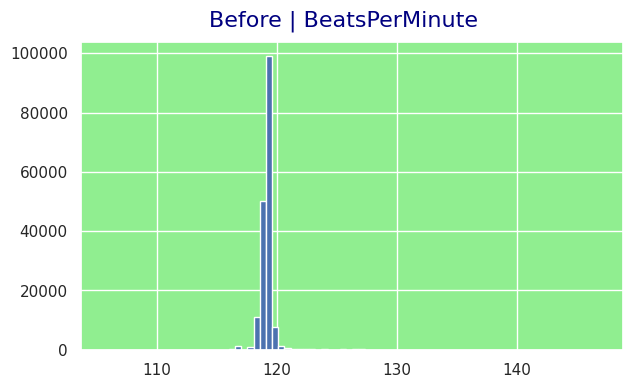

In [9]:
# Thanks to: @princevegeta515 - Best Public Score: 26.38135
sub_import = pd.read_csv('../input/tiny-nudges-big-gains-public-score-26-38135/submission.csv') 
per = sub_import['BeatsPerMinute'].values

# ..................................................................................................
sns.set()
plt.figure(figsize=(7, 4))
plt.hist(per, bins=80)

plt.gca().set_facecolor('lightgreen')
plt.suptitle('Before | BeatsPerMinute', y=0.96, fontsize=16, c='navy')

# ..................................................................................................
min_per = np.min(per)
print('Min:', round(min_per,3))

max_per = np.max(per)
print('Max:', round(max_per,3))

mean_per = np.mean(per)
print('Mean:', round(mean_per,3))

In [10]:
R = 0.0    # Adjusting the R value can increase the accuracy of the guide.
guide = mean_per - R

# ....................................
per1 = [f for f in per if f < guide]
per2 = [f for f in per if f > guide]

len(per1), len(per2)

(78625, 96097)

Min: 105.056
Max: 146.823
Mean: 119.187


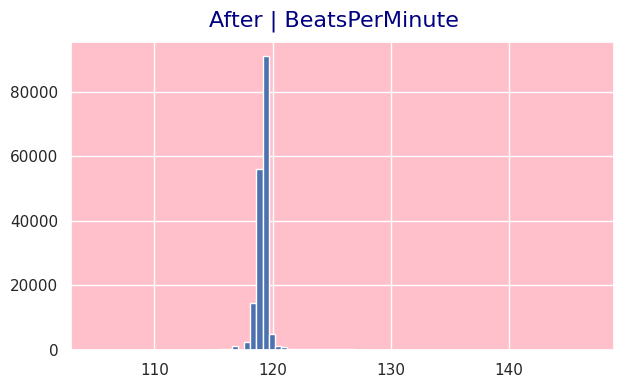

In [11]:
for i in range(len(per)):
    per_guide = (per[i] + guide) / 2
        
    if per[i] <= guide:
        per[i] = (per[i]* 1.10) - (per_guide* 0.10)

    if per[i] > guide:
        per[i] = (per[i]* 1.00) - (per_guide* 0.00)

# .......................................................................
sns.set()
plt.figure(figsize=(7, 4))
plt.hist(per, bins=80)

plt.gca().set_facecolor('pink')
plt.suptitle('After | BeatsPerMinute', y=0.96, fontsize=16, c='navy')

# .......................................................................
min_per = np.min(per)
print('Min:', round(min_per,3))

max_per = np.max(per)
print('Max:', round(max_per,3))

mean_per = np.mean(per)
print('Mean:', round(mean_per,3))

In [12]:
sub_sample['BeatsPerMinute'] = per
sub_sample.to_csv('submission_snap2.csv', index=False) 
sub_sample     # Public Score: 26.38124

,id,BeatsPerMinute
0,524164,119.230348
1,524165,118.934344
2,524166,119.479130
3,524167,119.454458
4,524168,119.690123
...,...,...
174717,698881,119.511149
174718,698882,119.333907
174719,698883,119.259940
174720,698884,118.916373


## <span style="color:darkcyan;">🎵 Method 4: Coordinate via power</span>

Min: 100.941
Max: 146.597
Mean: 119.099


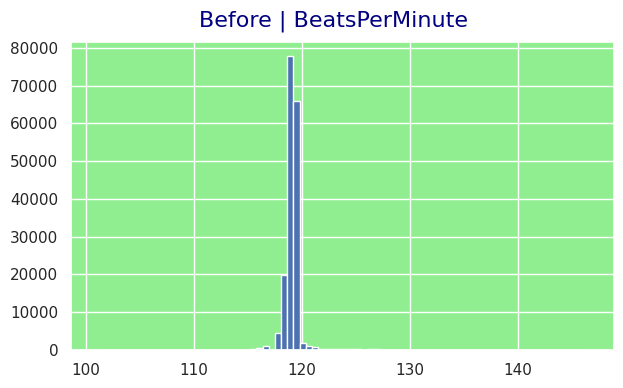

In [13]:
# Thanks to: @mikhailnaumov - Best Public Score: 26.38089
sub_import = pd.read_csv('../input/beats-per-minute-xgb-lgbm-hgb-nn-ydf/submission.csv') 
per = sub_import['BeatsPerMinute'].values

# ..................................................................................................
sns.set()
plt.figure(figsize=(7, 4))
plt.hist(per, bins=80)

plt.gca().set_facecolor('lightgreen')
plt.suptitle('Before | BeatsPerMinute', y=0.96, fontsize=16, c='navy')

# ..................................................................................................
min_per = np.min(per)
print('Min:', round(min_per,3))

max_per = np.max(per)
print('Max:', round(max_per,3))

mean_per = np.mean(per)
print('Mean:', round(mean_per,3))

In [14]:
R = 0.0    # Adjusting the R value can increase the accuracy of the guide.
guide = mean_per - R

# ....................................
per1 = [f for f in per if f < guide]
per2 = [f for f in per if f > guide]

len(per1), len(per2)

(73509, 101213)

Min: 97.733
Max: 151.806
Mean: 119.099


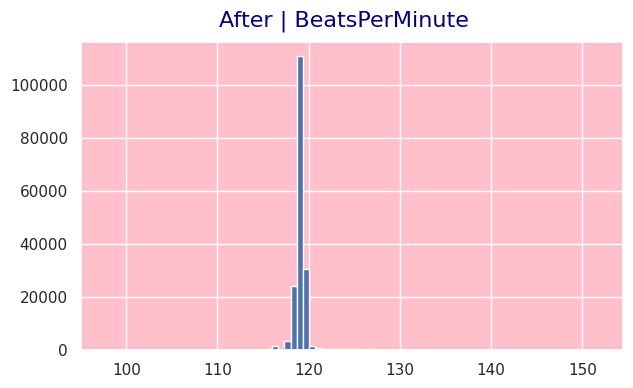

In [15]:
for i in range(len(per)):
        
    if per[i] < (min_per+7):
        per[i] = per[i] ** 0.993

    if per[i] > (max_per-9):
        per[i] = per[i] ** 1.007

# .......................................................................
sns.set()
plt.figure(figsize=(7, 4))
plt.hist(per, bins=80)

plt.gca().set_facecolor('pink')
plt.suptitle('After | BeatsPerMinute', y=0.96, fontsize=16, c='navy')

# .......................................................................
min_per = np.min(per)
print('Min:', round(min_per,3))

max_per = np.max(per)
print('Max:', round(max_per,3))

mean_per = np.mean(per)
print('Mean:', round(mean_per,3))

In [16]:
sub_sample['BeatsPerMinute'] = per
sub_sample.to_csv('submission_power.csv', index=False) 
sub_sample    # Public Score: 26.38078

,id,BeatsPerMinute
0,524164,119.193314
1,524165,118.818975
2,524166,119.360230
3,524167,119.403227
4,524168,119.591602
...,...,...
174717,698881,119.457005
174718,698882,119.283353
174719,698883,119.217416
174720,698884,118.829162


## <span style="color:darkcyan;">🎵 Method 5: Coordinate via Snap & Power</span>

Min: 103.566
Max: 145.181
Mean: 119.127


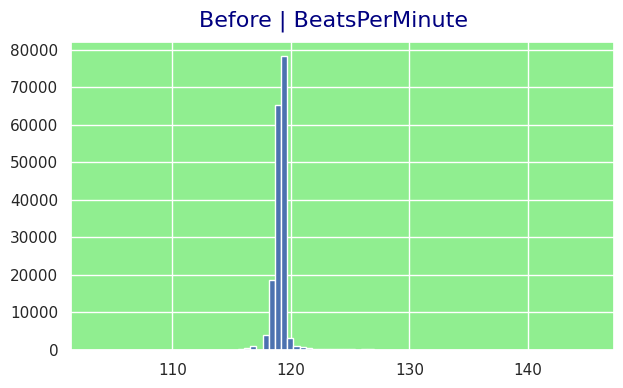

In [17]:
# Thanks to: @antonoof - Best Public Score: 26.38046
sub_import = pd.read_csv('../input/s5e9-26-38046/submission.csv') 
per = sub_import['BeatsPerMinute'].values

# ..................................................................................................
sns.set()
plt.figure(figsize=(7, 4))
plt.hist(per, bins=80)

plt.gca().set_facecolor('lightgreen')
plt.suptitle('Before | BeatsPerMinute', y=0.96, fontsize=16, c='navy')

# ..................................................................................................
min_per = np.min(per)
print('Min:', round(min_per,3))

max_per = np.max(per)
print('Max:', round(max_per,3))

mean_per = np.mean(per)
print('Mean:', round(mean_per,3))

In [18]:
R = 0.0    # Adjusting the R value can increase the accuracy of the guide.
guide = mean_per - R

# ....................................
per1 = [f for f in per if f < guide]
per2 = [f for f in per if f > guide]

len(per1), len(per2)

(77142, 97580)

Min: 100.843
Max: 145.181
Mean: 119.094


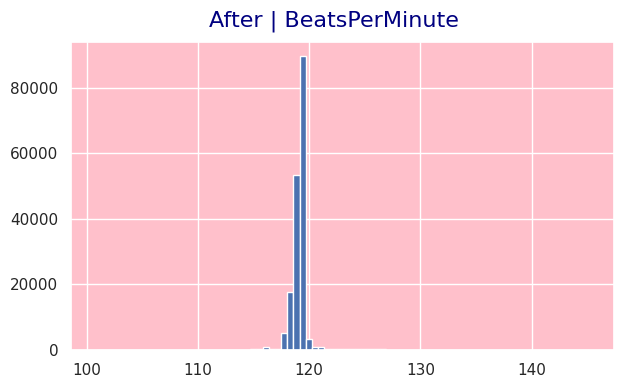

In [19]:
for i in range(len(per)):
    per_guide = (per[i] + guide) / 2
        
    if per[i] <= guide:
        per[i] = (per[i]* 1.35) - (per_guide* 0.35)

    if per[i] > guide:
        per[i] = (per[i]* 1.00) - (per_guide* 0.00)

# .......................................................................
sns.set()
plt.figure(figsize=(7, 4))
plt.hist(per, bins=80)

plt.gca().set_facecolor('pink')
plt.suptitle('After | BeatsPerMinute', y=0.96, fontsize=16, c='navy')

# .......................................................................
min_per = np.min(per)
print('Min:', round(min_per,3))

max_per = np.max(per)
print('Max:', round(max_per,3))

mean_per = np.mean(per)
print('Mean:', round(mean_per,3))

Min: 97.189
Max: 151.079
Mean: 119.094


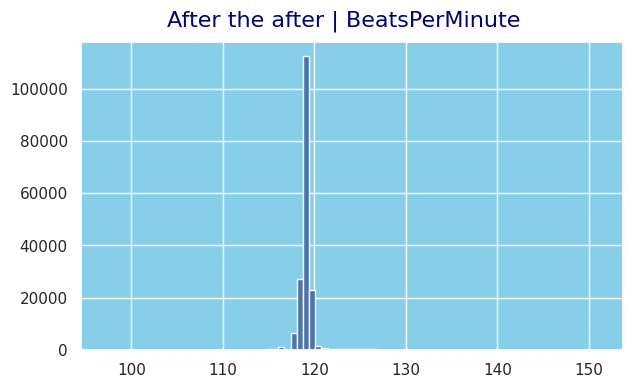

In [20]:
for i in range(len(per)):
        
    if per[i] < (min_per+7):
        per[i] = per[i] ** 0.992

    if per[i] > (max_per-9):
        per[i] = per[i] ** 1.008

# .......................................................................
sns.set()
plt.figure(figsize=(7, 4))
plt.hist(per, bins=80)

plt.gca().set_facecolor('skyblue')
plt.suptitle('After the after | BeatsPerMinute', y=0.96, fontsize=16, c='navy')

# .......................................................................
min_per = np.min(per)
print('Min:', round(min_per,3))

max_per = np.max(per)
print('Max:', round(max_per,3))

mean_per = np.mean(per)
print('Mean:', round(mean_per,3))

In [21]:
sub_sample['BeatsPerMinute'] = per
sub_sample.to_csv('submission_sn_po.csv', index=False) 
sub_sample     # Public Score: 26.38016

,id,BeatsPerMinute
0,524164,119.192615
1,524165,118.800954
2,524166,119.433577
3,524167,119.414487
4,524168,119.623185
...,...,...
174717,698881,119.453408
174718,698882,119.309165
174719,698883,119.216944
174720,698884,118.810758


## <span style="color:darkcyan;">🎵 Method 6: Coordinate via Range Change</span>

Min: 99.569
Max: 151.086
Mean: 119.051
Peak to Peak: 51.517


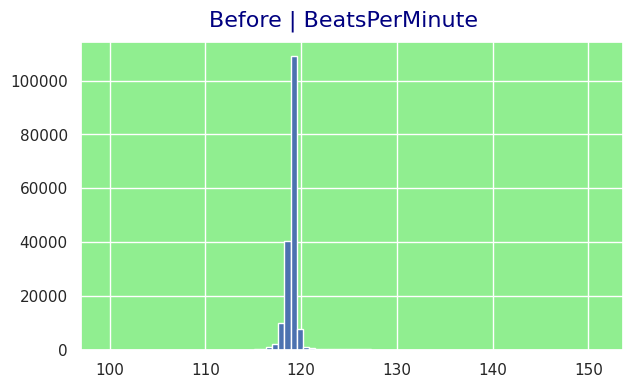

In [22]:
# Thanks to: @nina2025 - Best Public Score: 26.37992
sub_import = pd.read_csv('../input/s5e9-semi-final-1/submission.csv') 
per = sub_import['BeatsPerMinute'].values

# ..................................................................................................
sns.set()
plt.figure(figsize=(7, 4))
plt.hist(per, bins=80)

plt.gca().set_facecolor('lightgreen')
plt.suptitle('Before | BeatsPerMinute', y=0.96, fontsize=16, c='navy')

# ..................................................................................................
min_per = np.min(per)
print('Min:', round(min_per,3))

max_per = np.max(per)
print('Max:', round(max_per,3))

mean_per = np.mean(per)
print('Mean:', round(mean_per,3))

ptp_per = np.ptp(per)
print('Peak to Peak:', round(ptp_per,3))

In [23]:
def new_range(per, old_min, old_max, new_min, new_max):

    if (old_max == old_min): 
        return [new_min for p in per]

    new_per = []
    for p in per:
        if (old_min+7) < p < (old_max-9):
            new_per.append(p)
        else:
            percentage = (p - old_min) / (old_max - old_min)
            new_p = new_min + (percentage * (new_max - new_min))
            new_per.append(new_p)
            
    return new_per

# .......................................................................
per = new_range(per, min_per, max_per, 97.5, 152.0)
len(per) 

174722

Min: 97.5
Max: 152.0
Mean: 119.051
Peak to Peak: 54.5


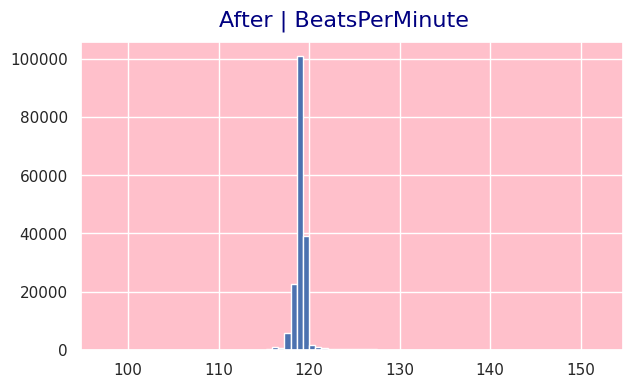

In [24]:
sns.set()
plt.figure(figsize=(7, 4))
plt.hist(per, bins=80)

plt.gca().set_facecolor('pink')
plt.suptitle('After | BeatsPerMinute', y=0.96, fontsize=16, c='navy')

# .......................................................................
min_per = np.min(per)
print('Min:', round(min_per,3))

max_per = np.max(per)
print('Max:', round(max_per,3))

mean_per = np.mean(per)
print('Mean:', round(mean_per,3))

ptp_per = np.ptp(per)
print('Peak to Peak:', round(ptp_per,3))

In [25]:
sub_sample['BeatsPerMinute'] = per
sub_sample.to_csv('submission_range.csv', index=False) 
sub_sample     # Public Score: 26.37988

,id,BeatsPerMinute
0,524164,119.139615
1,524165,118.733796
2,524166,119.305703
3,524167,119.402574
4,524168,119.594940
...,...,...
174717,698881,119.417503
174718,698882,119.292198
174719,698883,119.159230
174720,698884,118.781663


## <span style="color:darkcyan;">🎵 So what to do?</span>

- RMSE evaluation is weak and should not be used for multi-classification as well as regression with scattered results. Because the results of all methods will be inside the “RMSE Cage”.

- “Ensembling” methods may be able to improve your notebook score, but the scatter of your results will not increase and will not actually help this problem (RMSE Cage).

- The order and ranking of the numbers predicted by the notebooks is not accurate. This means that with the slightest chance, the RMSE equation may be out of the optimal state. And in practice, we can not simply increase the scatter of numbers.

- Please note that using the "Snap to curve" method, whether in this notebook or in a simple Ensembling, will definitely increase the risk of overfitting. These methods are mentioned only to better understand the weakness in RMSE Evaluation.

# <span style="color:darkcyan;">၊၊||၊ Coordinate at My Notebook</span>
<p style="border-bottom: 35px solid darkorange"></p>
<p style="border-bottom: 5px solid darkcyan"></p>

Min: 113.153
Max: 140.354
Mean: 119.034
Peak to Peak: 27.201


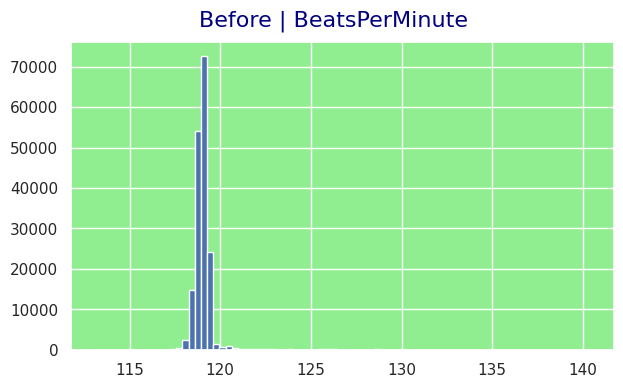

In [26]:
# My Notebook - Public Score: 26.38441
sub_import = pd.read_csv('../input/s5e9-songs-combine-features/submission.csv') 
per = sub_import['BeatsPerMinute'].values

# ..................................................................................................
sns.set()
plt.figure(figsize=(7, 4))
plt.hist(per, bins=80)

plt.gca().set_facecolor('lightgreen')
plt.suptitle('Before | BeatsPerMinute', y=0.96, fontsize=16, c='navy')

# ..................................................................................................
min_per = np.min(per)
print('Min:', round(min_per,3))

max_per = np.max(per)
print('Max:', round(max_per,3))

mean_per = np.mean(per)
print('Mean:', round(mean_per,3))

ptp_per = np.ptp(per)
print('Peak to Peak:', round(ptp_per,3))

Min: 111.559
Max: 142.452
Mean: 117.38
Peak to Peak: 30.892


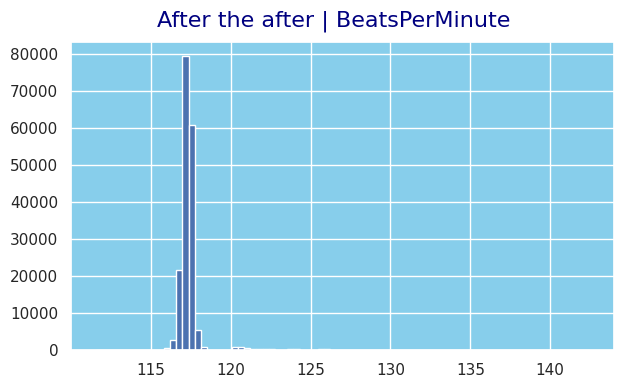

In [27]:
for i in range(len(per)):
        
    if per[i] < (min_per+7):
        per[i] = per[i] ** 0.997

    if per[i] > (max_per-9):
        per[i] = per[i] ** 1.003

# .......................................................................
sns.set()
plt.figure(figsize=(7, 4))
plt.hist(per, bins=80)

plt.gca().set_facecolor('skyblue')
plt.suptitle('After the after | BeatsPerMinute', y=0.96, fontsize=16, c='navy')

# ................................................................................
min_per = np.min(per)
print('Min:', round(min_per,3))

max_per = np.max(per)
print('Max:', round(max_per,3))

mean_per = np.mean(per)
print('Mean:', round(mean_per,3))

ptp_per = np.ptp(per)
print('Peak to Peak:', round(ptp_per,3))

In [28]:
sub_sample['BeatsPerMinute'] = per
sub_sample.to_csv('submission.csv', index=False) 
sub_sample     # Public Score: 

,id,BeatsPerMinute
0,524164,117.325531
1,524165,117.249382
2,524166,117.660942
3,524167,117.751975
4,524168,117.420428
...,...,...
174717,698881,117.607076
174718,698882,117.470798
174719,698883,117.342650
174720,698884,117.086928


<p style="border-bottom: 5px solid darkorange"></p>
<p style="border-bottom: 25px solid darkorange"></p>